# Purpose of the Code

The goal of this notebook is to perform feature selection and evaluate the performance of various machine learning models, identifying the optimal combination of features and models to improve predictive performance and reduce model complexity.

## Environment Setup

In [2]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [3]:
import os
import pandas as pd
import numpy as np
import sys
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from libemg.feature_selector import FeatureSelector
sys.path.append('../../lib')
from fs_utils import (plot_label_distribution, balance_via_undersampling, plot_feature_vs_label, plot_feature_correlation,
                        drop_highly_correlated_features, report_remaining_high_correlations, prepare_cv_data, plot_feature_accuracy,
                        plot_sequential_selection_heatmap, plot_feature_selection_performance, plot_pca_variance)
from me_utils import evaluate_emg_classifier, evaluate_and_store_results, print_results

In [4]:
# Parameters
device = "trigno"  # Devices: "trigno" or "myo"
date = "07_03"     # Recording date in MM_DD format
subj = "01"     # Subject ID, e.g., "01", "02", etc.
preferred_features = ['MAV', 'SSC', 'WL'] # List of preferred EMG features for selection
labels = ['no weight', 'light', 'medium', 'heavy'] # List of possible labels
label_map = {'no weight': 0, 'light': 1, 'medium': 2, 'heavy': 3} # Map string labels to integers for modeling
metric = "accuracy" # Metric used during feature selection, possible choice 
                    # between "accuracy", "activeerror", "meansemiprincipalaxis", "featureefficiency", "repeatability", "seperability"
n_folds = 5 # Number of folds to use for cross-validation for feature selection
th = 0.8 # Threshold for features with correlation
fs = FeatureSelector() # Initialize FeatureSelector object for feature selection tasks
scaler = StandardScaler() # Initialize StandardScaler object
results = {}  # Dictionary to store results scores keyed by model name

# Initialize variables based on device
if device == 'trigno':
    suffixes = ['_biceps', '_triceps']
    bins = [0, 0.15, 0.35, 0.53, np.inf]
    labels_MAV = ['0-0.15', '0.15-0.35', '0.35-0.53', '0.53+']
    ref_feature = "MAV_biceps"
elif device == 'myo':
    suffixes = ['_channel_1', '_channel_2', '_channel_3', '_channel_4',
                '_channel_5', '_channel_6', '_channel_7', '_channel_8']
    bins = [0, 0.10, 0.27, 0.47, np.inf]
    labels_MAV = ['0-0.10', '0.10-0.27', '0.27-0.47', '0.47+']
    ref_feature = "MAV_channel_6"

# Paths for input and output
input_folder = f'../../data/extracted_features/{device}/S{subj}_{date}/'  # Input folder with raw data
output_folder = f'../../data/models/{device}/S{subj}_{date}'  # Output folder

# Loading Data Files

In [5]:
csv_files = [file for file in os.listdir(input_folder) if file.endswith('.csv')]
df = pd.read_csv(os.path.join(input_folder, csv_files[0])) # Read the first CSV file in the list into a DataFrame
df.head()

,ISD_biceps,KURT_biceps,LD_biceps,MAV_biceps,MNF_biceps,MNP_biceps,MPK_biceps,RMS_biceps,SAMPEN_biceps,SKEW_biceps,...,RMS_triceps,SAMPEN_triceps,SKEW_triceps,SM_triceps,SSC_triceps,VAR_triceps,WAMP_triceps,WL_triceps,ZC_triceps,label
0,0.065313,2.688531,1.016129,0.016129,0.778836,0.000002,0.016569,0.016131,0.013346,0.105132,...,0.035147,0.046021,0.388425,0.184729,101,2.761696e-07,67,0.003473,63,no weight
1,0.064456,3.445030,1.016018,0.016018,0.750906,0.000002,0.016569,0.016025,0.018810,-0.193568,...,0.038096,0.009926,0.300691,0.240283,106,1.469044e-05,69,0.012823,60,no weight
2,0.056592,3.626785,1.014995,0.014996,0.812639,0.000002,0.016350,0.015016,0.004694,-0.194307,...,0.046580,0.002058,0.076006,0.313083,102,3.521249e-05,90,0.019804,57,no weight
3,0.050918,2.972091,1.014240,0.014240,0.837510,0.000002,0.014983,0.014243,0.032291,0.020772,...,0.054943,0.001381,-0.096983,0.416019,94,1.729898e-05,97,0.014551,49,no weight
4,0.052037,3.592662,1.014396,0.014396,0.790893,0.000002,0.014877,0.014399,0.000558,-0.111994,...,0.060809,0.005339,-0.113830,0.519235,93,8.272291e-06,91,0.009872,44,no weight


In [6]:
df.info(max_cols=10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12672 entries, 0 to 12671
Columns: 34 entries, ISD_biceps to label
dtypes: float64(27), int64(6), object(1)
memory usage: 3.3+ MB


In [7]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42) # Split into train (70%) and test (30%)
print("Train set:", train_df.shape)
print("Test set:", test_df.shape)

Train set: (8870, 34)
Test set: (3802, 34)


# Exploratory Data Analysis (EDA)

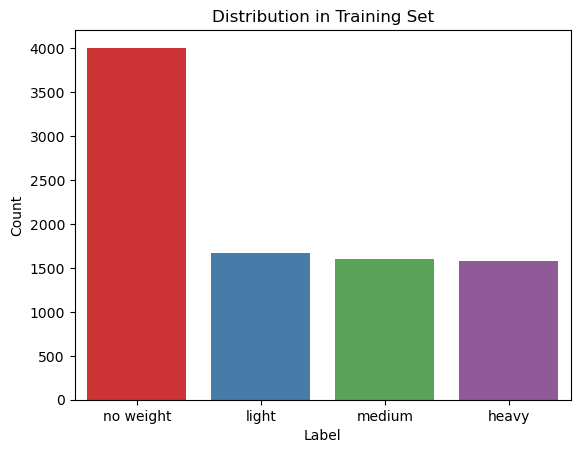

In [8]:
plot_label_distribution(train_df, labels, title='Distribution in Training Set') # Plot train set distribution

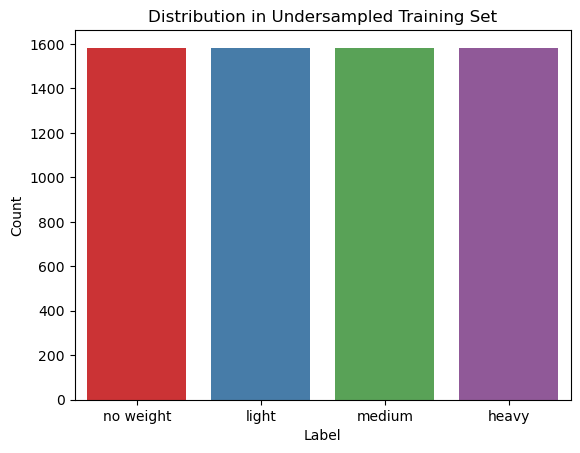

In [9]:
# Check class distribution counts
counts = train_df['label'].value_counts()
min_count = counts.min()
max_count = counts.max()

if max_count != min_count:
    train_df = balance_via_undersampling(train_df, label_col='label')
    plot_label_distribution(train_df, labels, title='Distribution in Undersampled Training Set')
else:
    print("Classes are already balanced. No undersampling performed.")

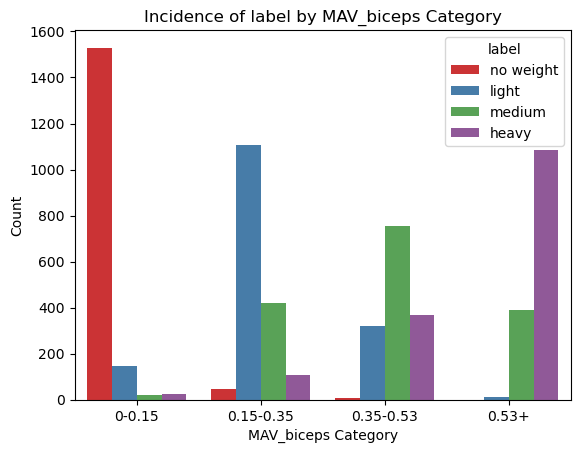

In [10]:
# Example: Correlation label-feature (MAV)
plot_feature_vs_label(train_df, ref_feature, bins, labels_MAV)

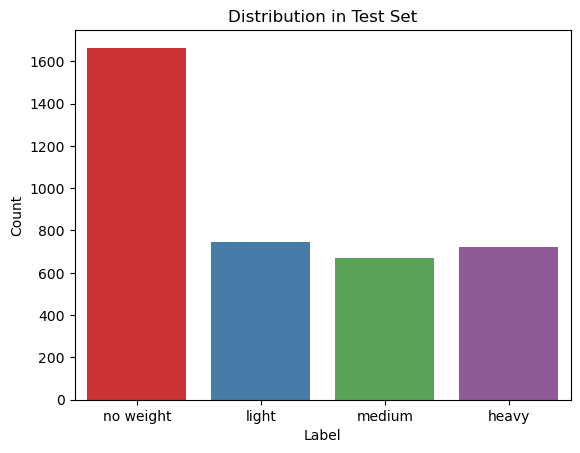

In [11]:
plot_label_distribution(test_df, labels, title='Distribution in Test Set') # Plot test set distribution

# Feature Engineering

## Feature Correlation Selection

In [12]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
y = y_train.map(label_map)  # Convert label strings to numeric values using label_map  
X = scaler.fit_transform(X_train) # Scale features to zero mean and unit variance to normalize data
X = pd.DataFrame(X, columns=X_train.columns, index=X_train.index) # Scaled dataframe with column names

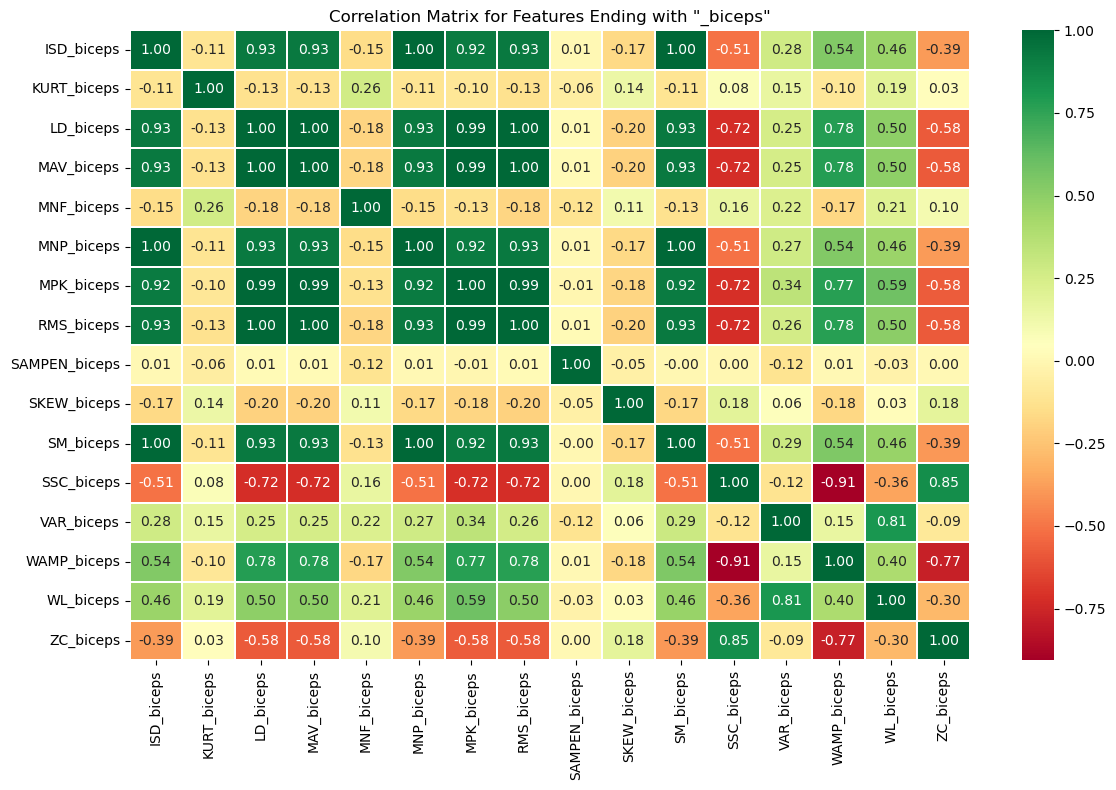

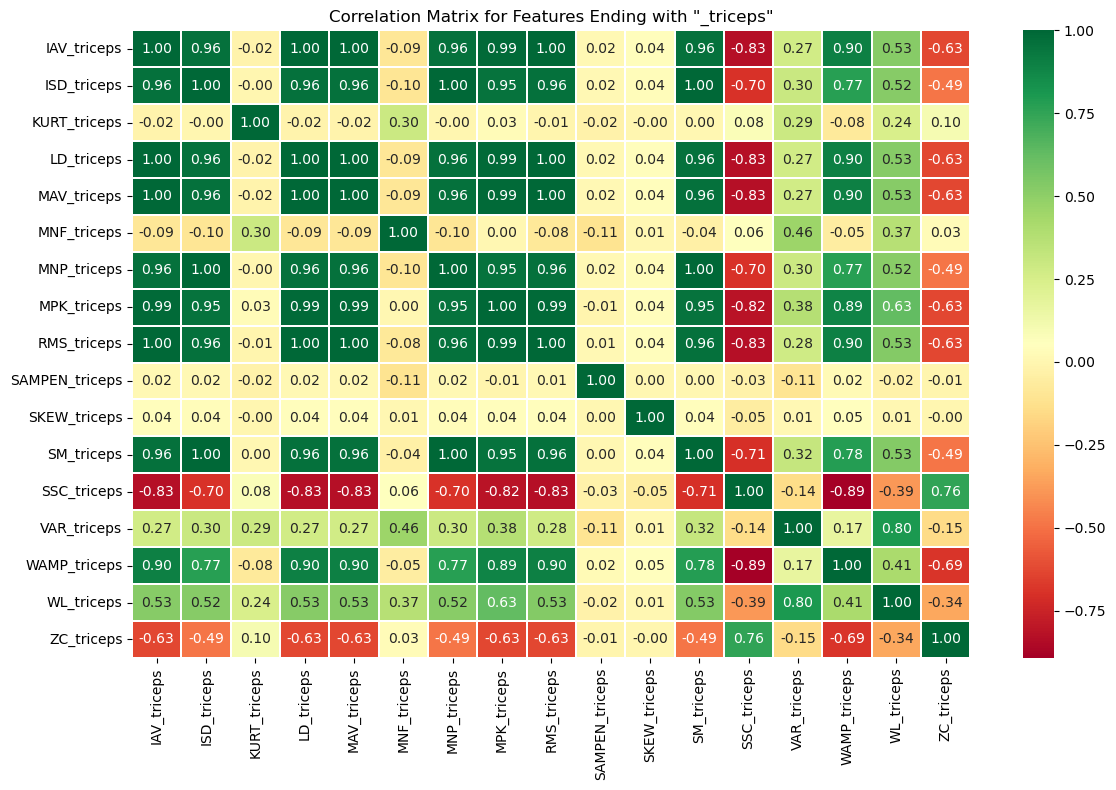

In [13]:
plot_feature_correlation(X, suffixes) # Plot correlation matrices for groups of features (each muscle/channel)

In [14]:
# Drop redundant features within each muscle group, keeping only preferred ones
X_red = drop_highly_correlated_features(X, suffixes, preferred_features, th)
print(f"Total remaining features: {len(X_red.columns)}")

Total remaining features: 15


In [15]:
report_remaining_high_correlations(X_red, suffixes, th)

Remaining highly correlated features (>0.8 intra-channel, >0.9 inter-channel) after filtering:
High correlations:
  (Intra-channel "_triceps") SSC_triceps and MAV_triceps correlated: 0.83


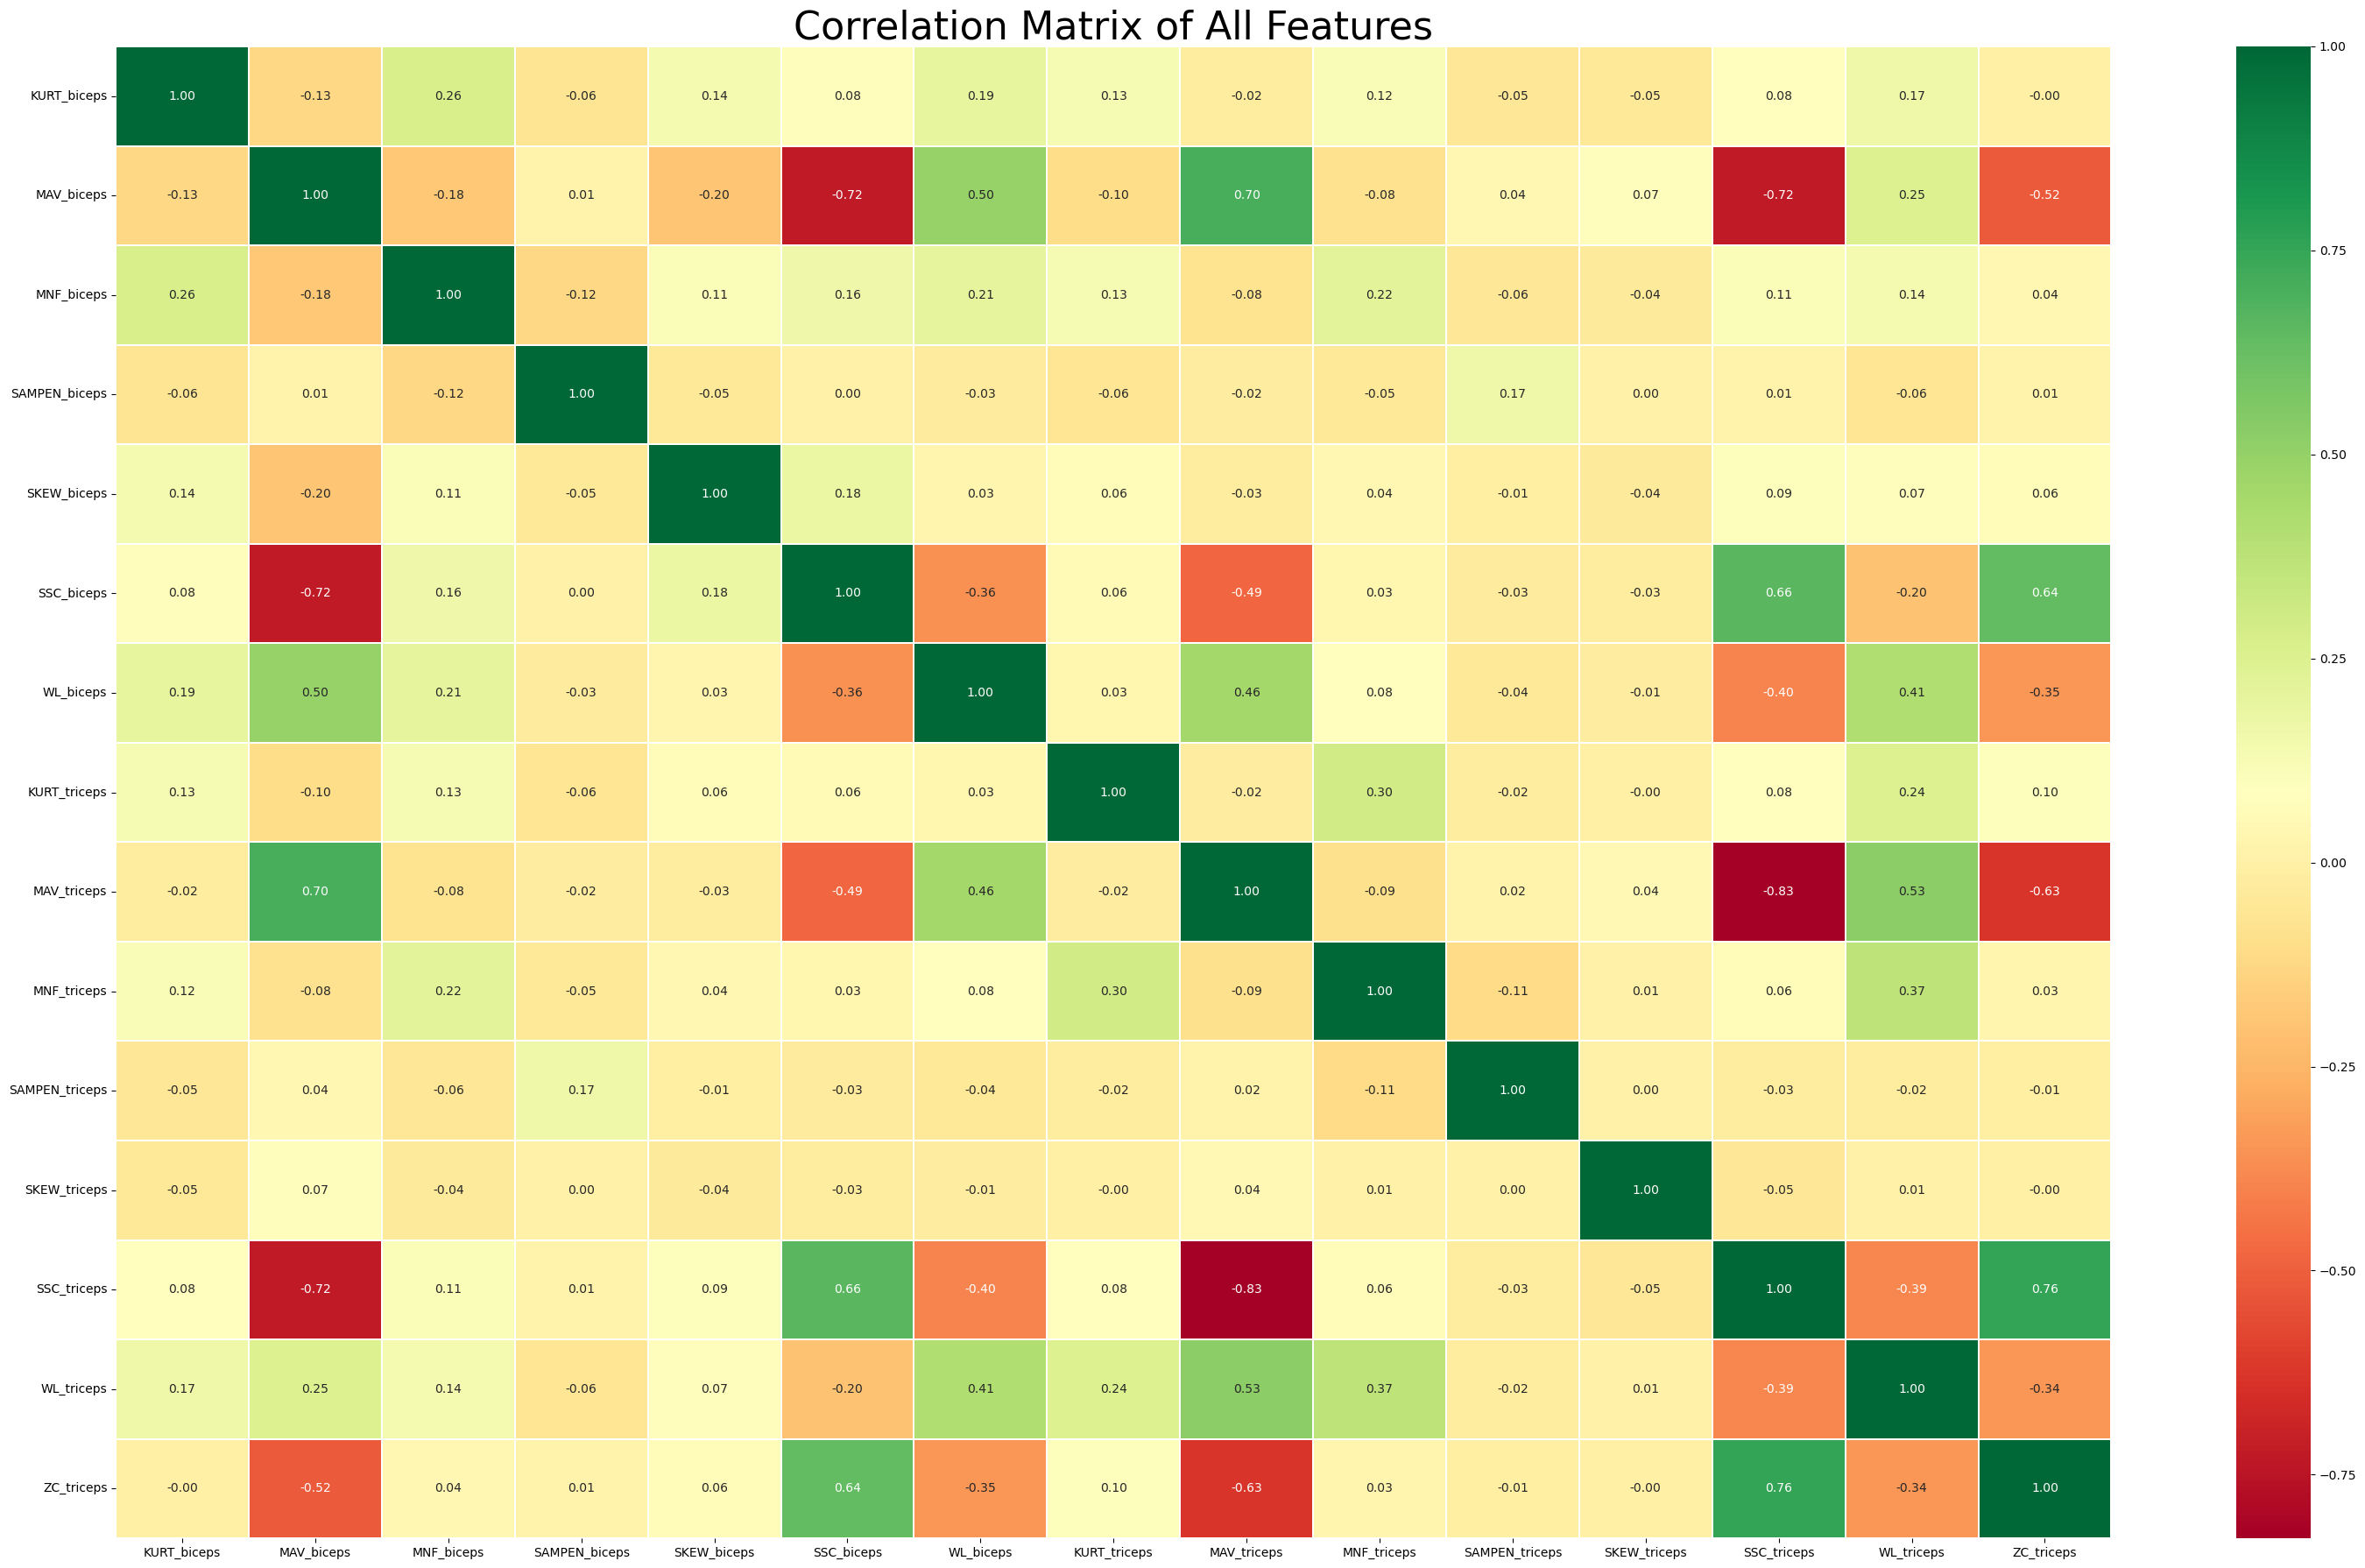

In [16]:
plot_feature_correlation(X_red, all_features=True) # Plot overall correlation matrix for all remaining features

## Feature Wrapping Selection

In [17]:
crossvalidation_var, data_dict = prepare_cv_data(X_red, n_folds, random_state=42) # Prepare cross-validation fold labels and dict for feature selection
accuracy_results, accuracy_fs = fs.run_selection(data_dict, metric, y, crossvalidation_var) # Run feature selection

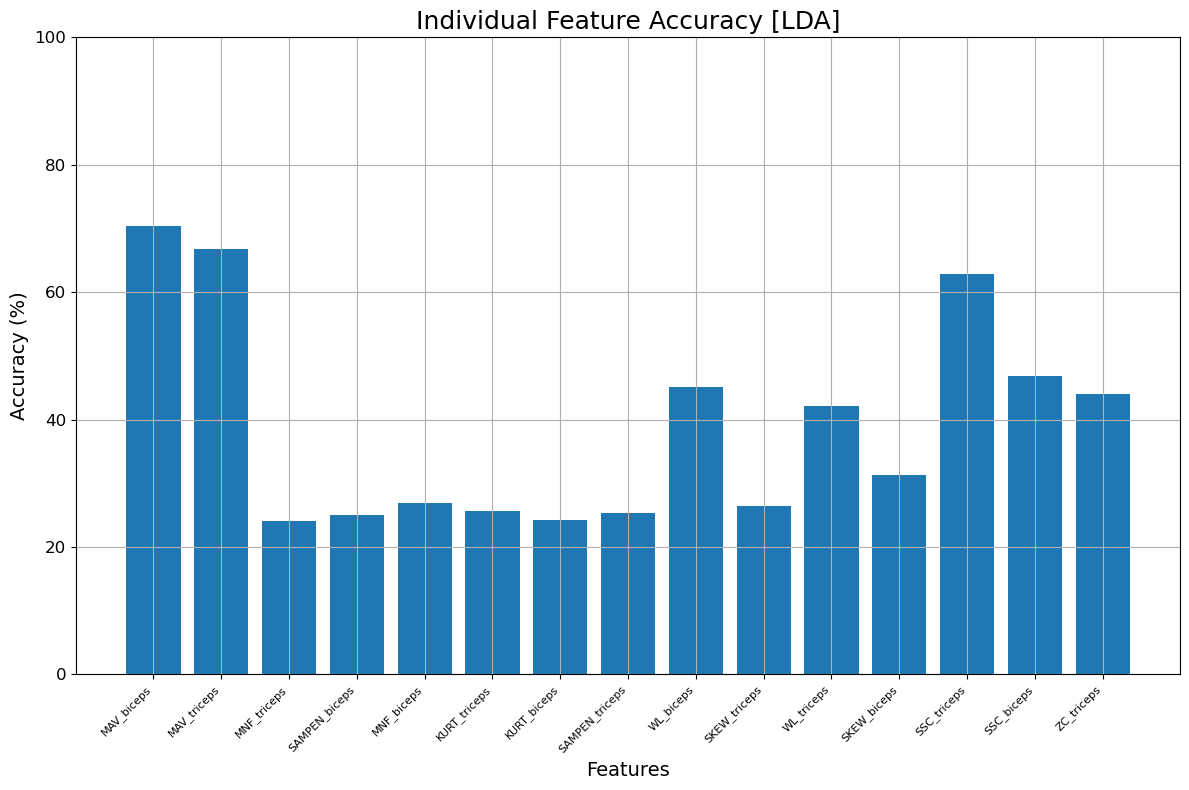

In [18]:
plot_feature_accuracy(accuracy_fs, accuracy_results[0])

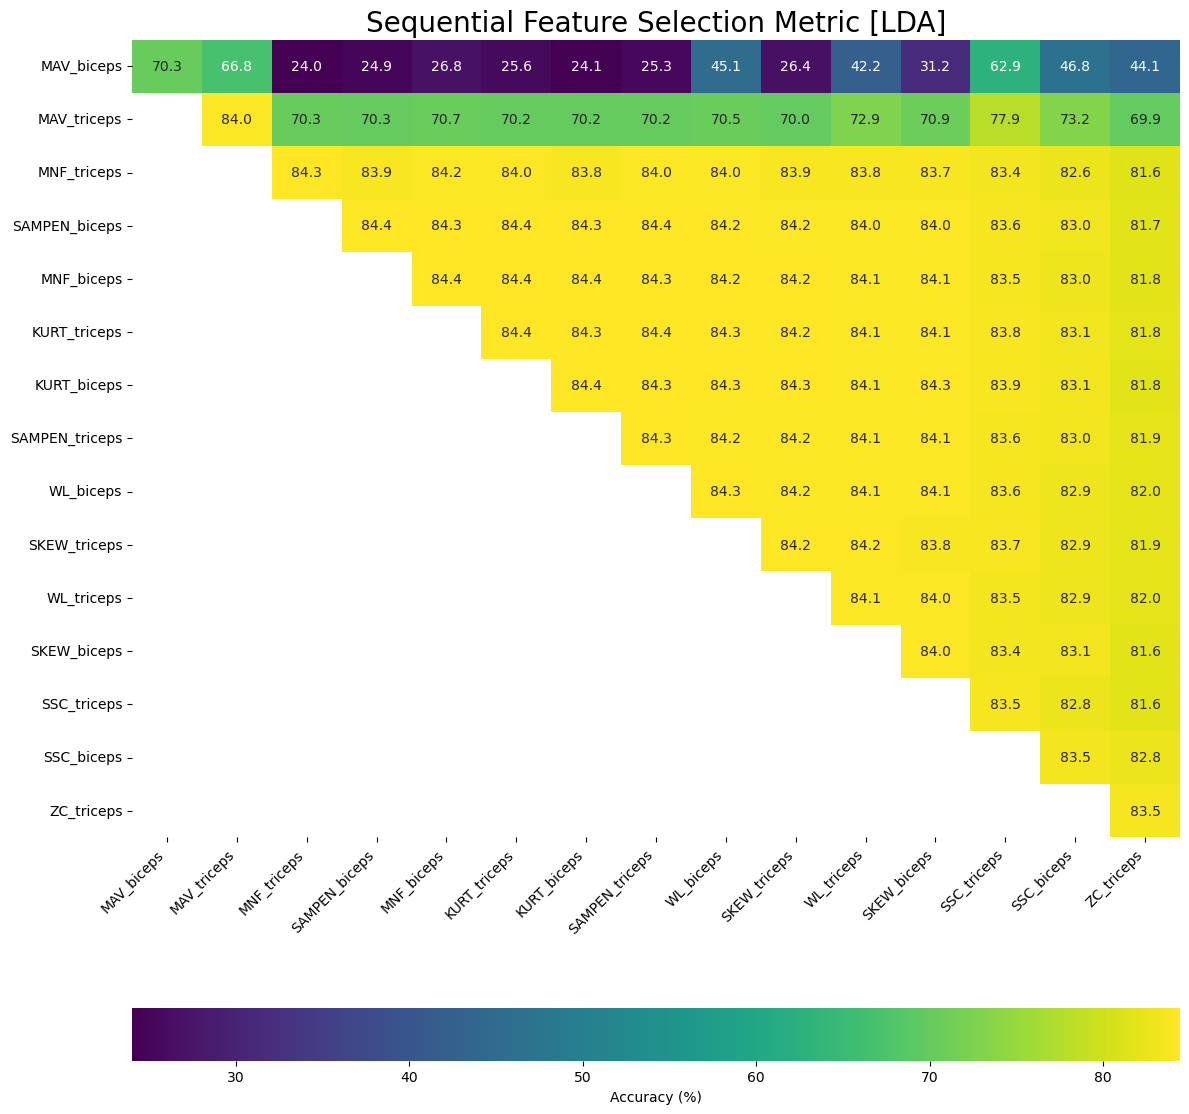

In [19]:
plot_sequential_selection_heatmap(accuracy_results, accuracy_fs)

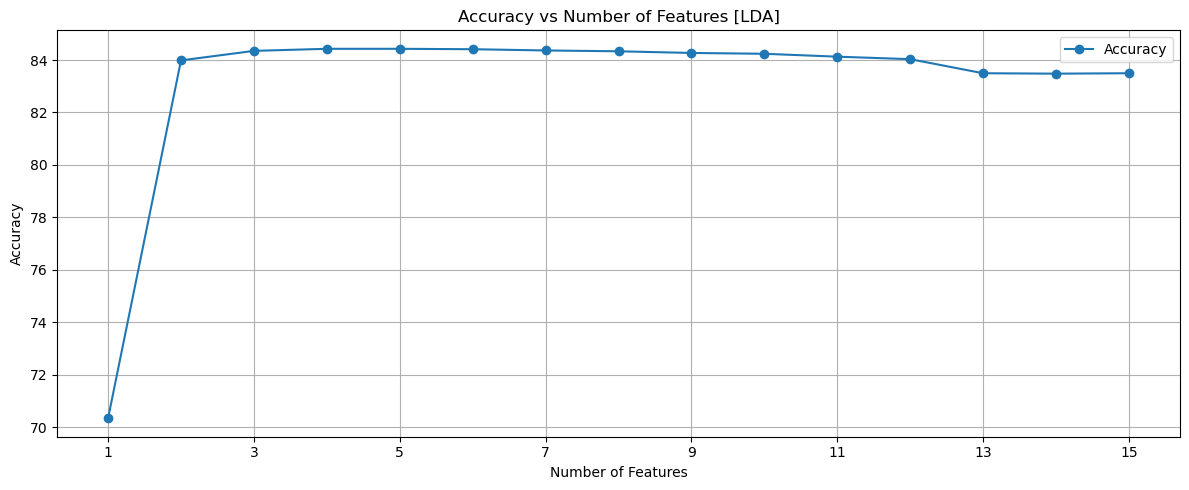

In [20]:
res = list(zip(range(1, len(np.diag(accuracy_results)) + 1), np.diag(accuracy_results)))
plot_feature_selection_performance(res, "LDA") # Plot accuracy to assess performance trends

## Principal Component Analysis (PCA)

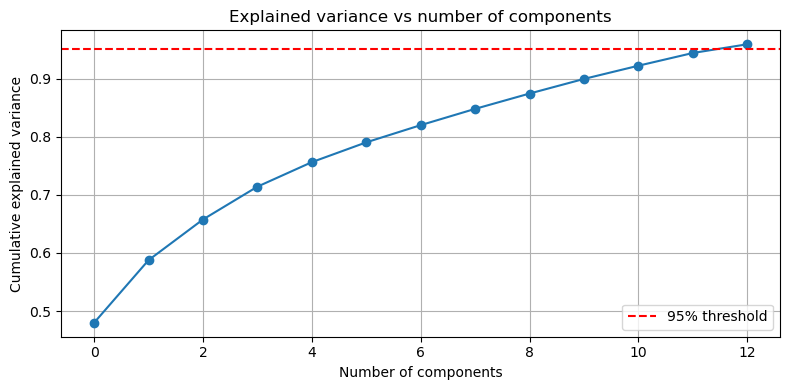

In [21]:
pca = PCA(n_components=0.95)  # Keep the number of components that explain 95% of the variance
X_pca = pca.fit_transform(X)  # Fit PCA on X and transform it to the reduced component space
plot_pca_variance(pca)        # Plot cumulative explained variance to visualize component contribution

## Scaler, PCA, ordered columns export

In [23]:
joblib.dump(scaler, f'{output_folder}/scaler.pkl')
joblib.dump(pca, f'{output_folder}/pca.pkl')
joblib.dump(accuracy_fs, f'{output_folder}/selected_col.pkl')

['../../data/models/trigno/S01_07_03/selected_col.pkl']

# Model Evaluation

In [25]:
# Feature Set Preparation
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']
X_test = scaler.transform(X_test) # Apply same scaling used on training data to test set
X_test = pd.DataFrame(X_test, columns=X.columns, index=y_test.index) # Scaled dataframe with column names
selected_columns = accuracy_fs[:6]  # Wrapping Selection

X_train1 = X # Original feature set (no reduction or selection)
X_train2 = X_red # Reduced feature set (e.g., after removing highly correlated features)
X_train3 = X[selected_columns] # Wrapping selected feature set
X_train4 = X_pca # PCA feature set 
X_train5 = X.filter(regex=r'^(MAV|ZC|SSC|WL)', axis=1) # Hudgins Columns

X_test1 = X_test 
X_test2 = X_test[X_red.columns]
X_test3 = X_test[selected_columns] 
X_test4 = pca.transform(X_test) 
X_test4 = pd.DataFrame(X_test4, index=y_test.index) 
X_test5 = X_test.filter(regex=r'^(MAV|ZC|SSC|WL)', axis=1)

feature_sets_train = [X_train1, X_train2, X_train3, X_train4, X_train5]
feature_sets_test = [X_test1, X_test2, X_test3, X_test4, X_test5]

y_train = y # Train label array
y_test = y_test.map(label_map)  # Convert label strings to numeric values using label_map  

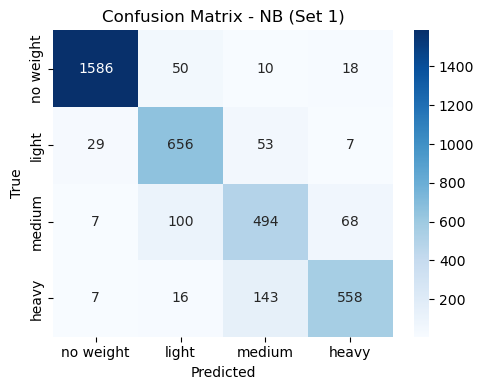

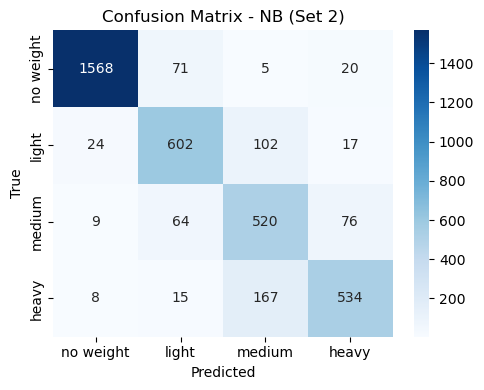

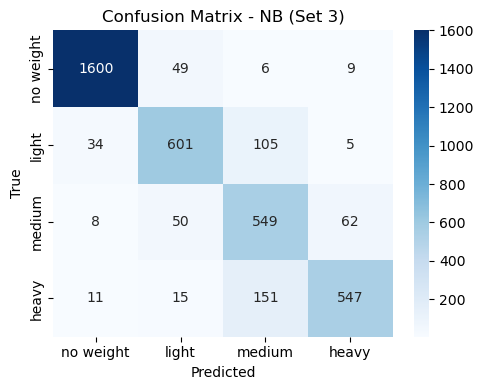

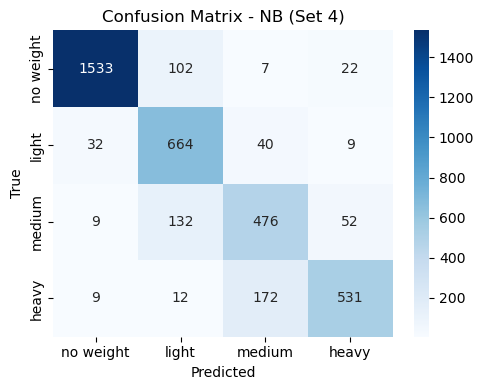

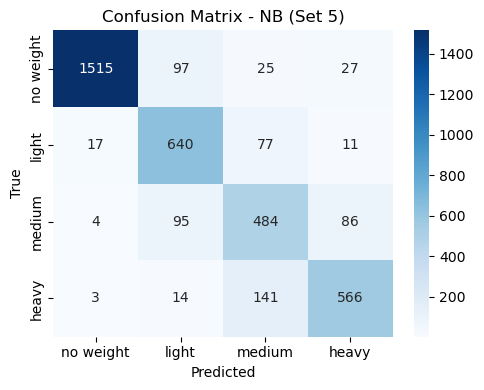

-------- NB Classifier - Evaluation Metrics --------
Accuracy: Set 1: 86.64% | Set 2: 84.80% | Set 3: 86.72% | Set 4: 84.27% | Set 5: 84.30%
Precision: Set 1: 86.99% | Set 2: 85.58% | Set 3: 87.46% | Set 4: 85.20% | Set 5: 85.24%
Recall: Set 1: 86.64% | Set 2: 84.80% | Set 3: 86.72% | Set 4: 84.27% | Set 5: 84.30%
F1: Set 1: 86.72% | Set 2: 85.04% | Set 3: 86.88% | Set 4: 84.45% | Set 5: 84.61%
Training_time: Set 1: 0.0080 s | Set 2: 0.0050 s | Set 3: 0.0055 s | Set 4: 0.0030 s | Set 5: 0.0040 s
Inference_time: Set 1: 1.5410 ms | Set 2: 1.2795 ms | Set 3: 1.1967 ms | Set 4: 1.2711 ms | Set 5: 1.3240 ms


In [26]:
#################################### Naive Bayes ########################
model_name = 'NB'
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder)
print_results(model_name, results[model_name])

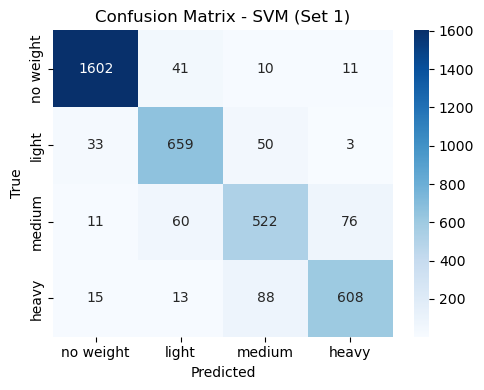

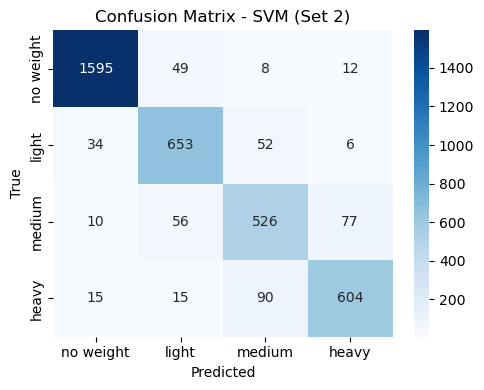

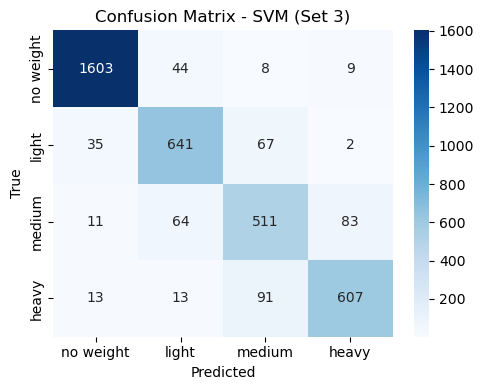

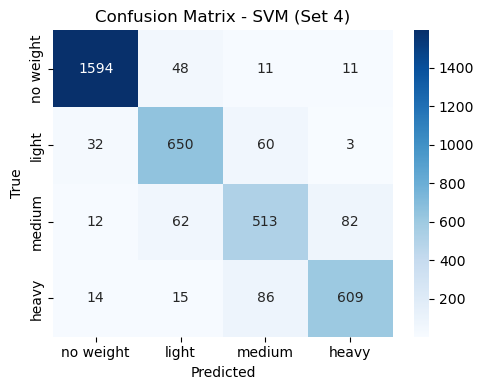

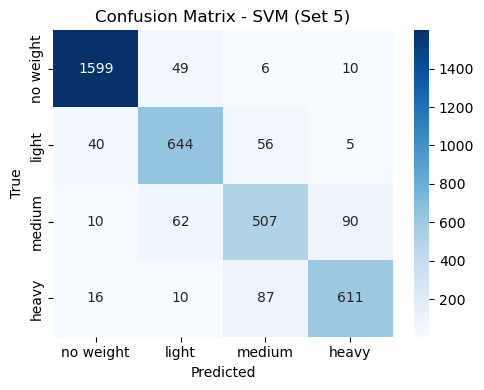

-------- SVM Classifier - Evaluation Metrics --------
Accuracy: Set 1: 89.19% | Set 2: 88.85% | Set 3: 88.43% | Set 4: 88.53% | Set 5: 88.40%
Precision: Set 1: 89.21% | Set 2: 88.90% | Set 3: 88.47% | Set 4: 88.59% | Set 5: 88.38%
Recall: Set 1: 89.19% | Set 2: 88.85% | Set 3: 88.43% | Set 4: 88.53% | Set 5: 88.40%
F1: Set 1: 89.19% | Set 2: 88.86% | Set 3: 88.44% | Set 4: 88.55% | Set 5: 88.38%
Training_time: Set 1: 4.7109 s | Set 2: 4.6077 s | Set 3: 3.4692 s | Set 4: 3.8368 s | Set 5: 3.2966 s
Inference_time: Set 1: 1.4498 ms | Set 2: 1.3640 ms | Set 3: 1.2644 ms | Set 4: 1.2906 ms | Set 5: 1.3321 ms


In [27]:
#################################### SVM ########################
model_name = 'SVM' 
svm_params = {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True}
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder, svm_params)
print_results(model_name, results[model_name])

C:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nicol\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nicol\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nicol\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

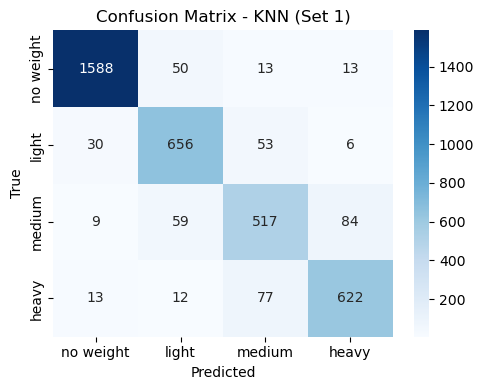

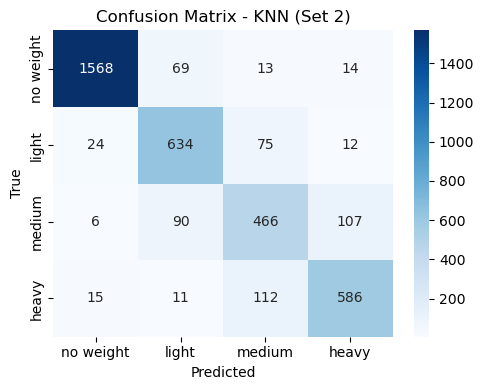

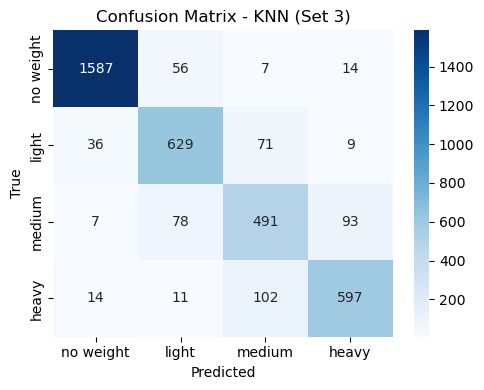

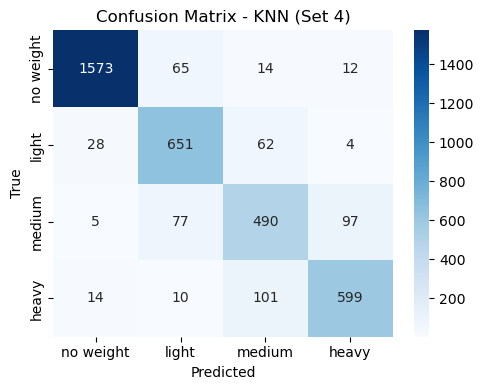

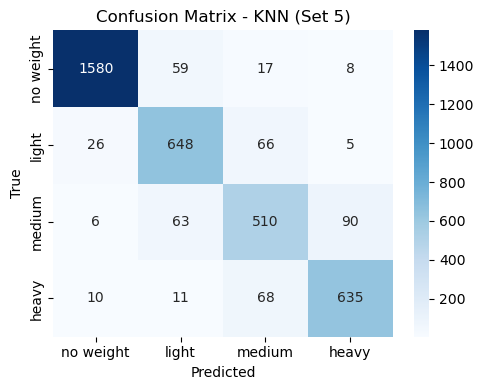

-------- KNN Classifier - Evaluation Metrics --------
Accuracy: Set 1: 88.98% | Set 2: 85.59% | Set 3: 86.90% | Set 4: 87.14% | Set 5: 88.72%
Precision: Set 1: 89.04% | Set 2: 85.83% | Set 3: 86.99% | Set 4: 87.33% | Set 5: 88.85%
Recall: Set 1: 88.98% | Set 2: 85.59% | Set 3: 86.90% | Set 4: 87.14% | Set 5: 88.72%
F1: Set 1: 89.00% | Set 2: 85.67% | Set 3: 86.94% | Set 4: 87.20% | Set 5: 88.77%
Training_time: Set 1: 0.0053 s | Set 2: 0.0204 s | Set 3: 0.0090 s | Set 4: 0.0110 s | Set 5: 0.0104 s
Inference_time: Set 1: 1.6057 ms | Set 2: 2.1703 ms | Set 3: 1.7599 ms | Set 4: 2.2329 ms | Set 5: 1.9545 ms


In [28]:
#################################### KNN ########################
model_name = 'KNN'
knn_params = {'n_neighbors': 5, 'weights': 'distance', 'metric': 'manhattan', 'p': 1, 'algorithm': 'auto'}
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder, knn_params)
print_results(model_name, results[model_name])

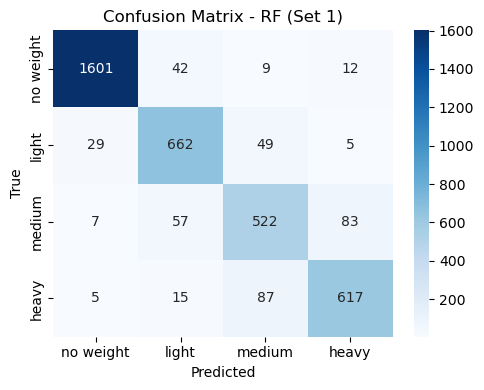

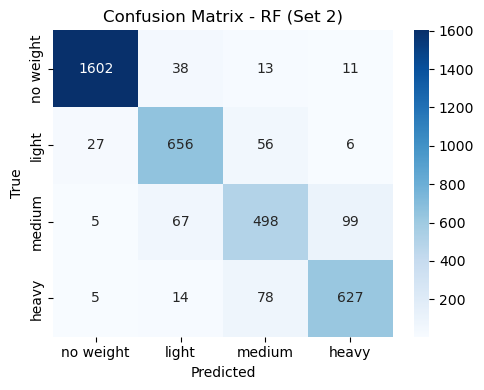

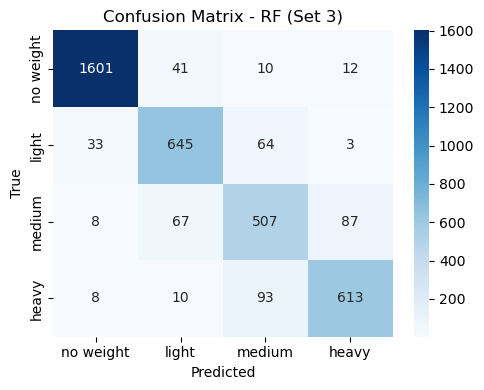

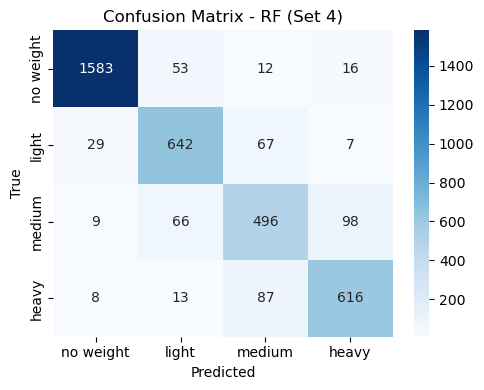

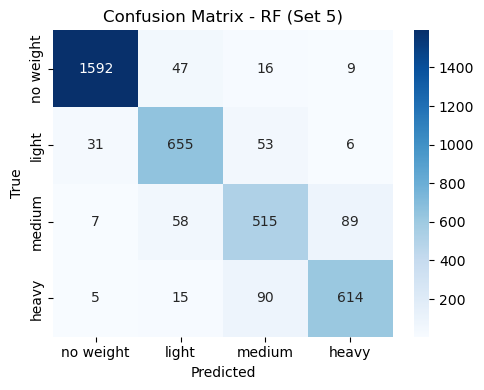

-------- RF Classifier - Evaluation Metrics --------
Accuracy: Set 1: 89.48% | Set 2: 88.98% | Set 3: 88.53% | Set 4: 87.77% | Set 5: 88.80%
Precision: Set 1: 89.55% | Set 2: 89.02% | Set 3: 88.59% | Set 4: 87.88% | Set 5: 88.91%
Recall: Set 1: 89.48% | Set 2: 88.98% | Set 3: 88.53% | Set 4: 87.77% | Set 5: 88.80%
F1: Set 1: 89.50% | Set 2: 88.98% | Set 3: 88.56% | Set 4: 87.81% | Set 5: 88.84%
Training_time: Set 1: 0.3956 s | Set 2: 0.2967 s | Set 3: 0.2622 s | Set 4: 0.2902 s | Set 5: 0.2137 s
Inference_time: Set 1: 25.7775 ms | Set 2: 25.8875 ms | Set 3: 25.8871 ms | Set 4: 26.0088 ms | Set 5: 25.8756 ms


In [29]:
#################################### Random Forest ########################
model_name = 'RF'  
rf_params = {'n_estimators': 30, 'min_samples_split': 30, 'max_features': 'sqrt', 'max_depth': 10, 'oob_score': True, 'random_state': 1, 'n_jobs': -1}
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder, rf_params)
print_results(model_name, results[model_name])

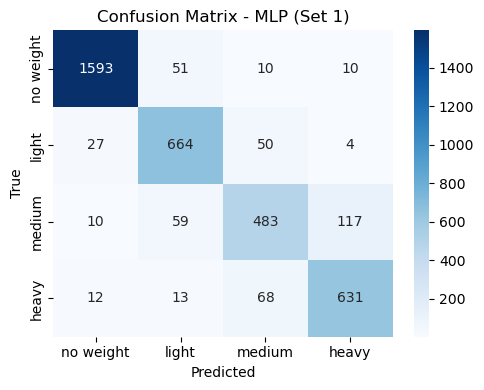

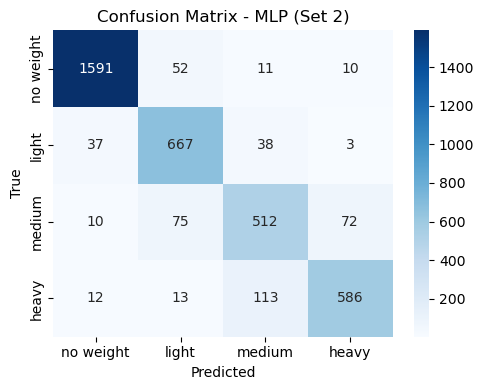

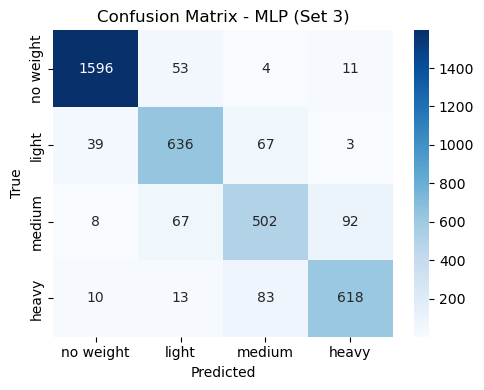

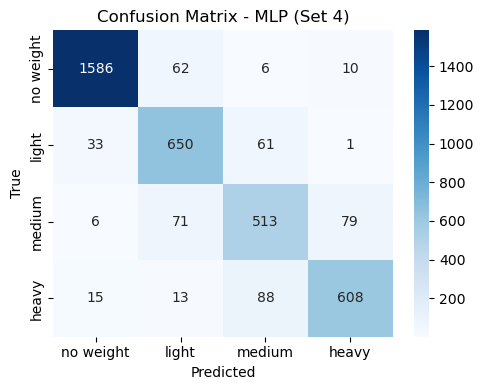

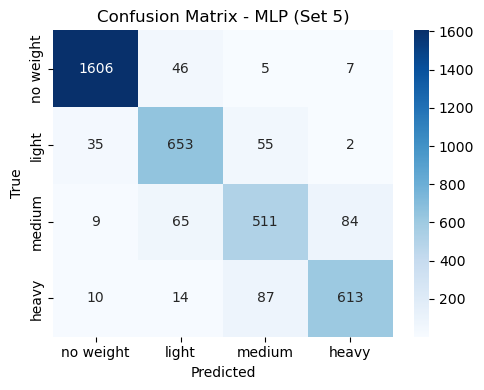

-------- MLP Classifier - Evaluation Metrics --------
Accuracy: Set 1: 88.66% | Set 2: 88.27% | Set 3: 88.16% | Set 4: 88.30% | Set 5: 88.98%
Precision: Set 1: 88.67% | Set 2: 88.39% | Set 3: 88.18% | Set 4: 88.43% | Set 5: 88.99%
Recall: Set 1: 88.66% | Set 2: 88.27% | Set 3: 88.16% | Set 4: 88.30% | Set 5: 88.98%
F1: Set 1: 88.62% | Set 2: 88.28% | Set 3: 88.17% | Set 4: 88.34% | Set 5: 88.97%
Training_time: Set 1: 3.6433 s | Set 2: 2.8923 s | Set 3: 4.0185 s | Set 4: 3.9842 s | Set 5: 3.2202 s
Inference_time: Set 1: 1.1754 ms | Set 2: 1.3635 ms | Set 3: 1.1009 ms | Set 4: 1.0598 ms | Set 5: 1.0157 ms


In [30]:
#################################### Neural Network ########################
model_name = 'MLP'  
mlp_params ={ 'hidden_layer_sizes': (100, 50, 30), 'activation': 'relu', 'solver': 'adam', 'max_iter': 500, 'early_stopping': True, 'alpha': 0.0001}
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder, mlp_params)
print_results(model_name, results[model_name])

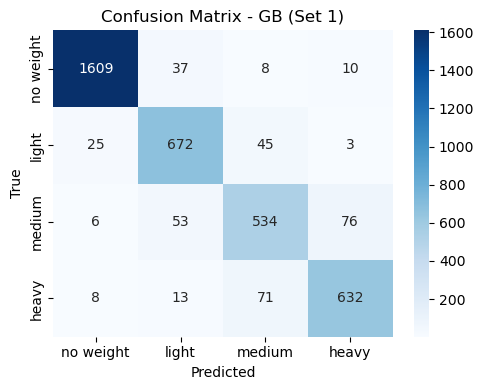

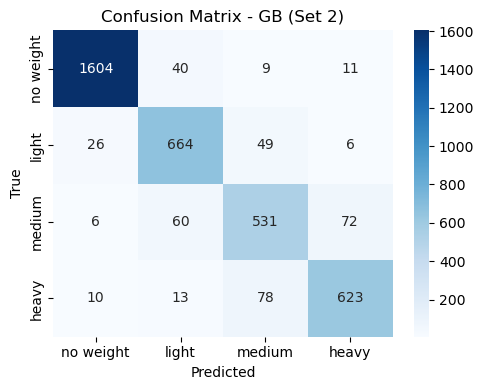

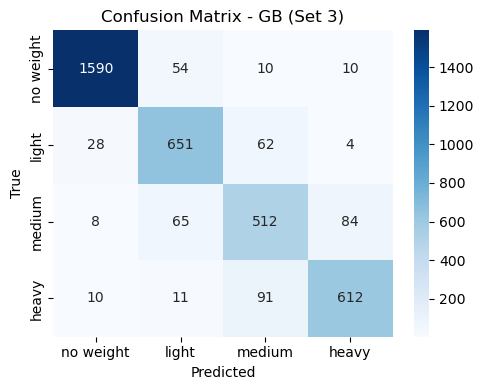

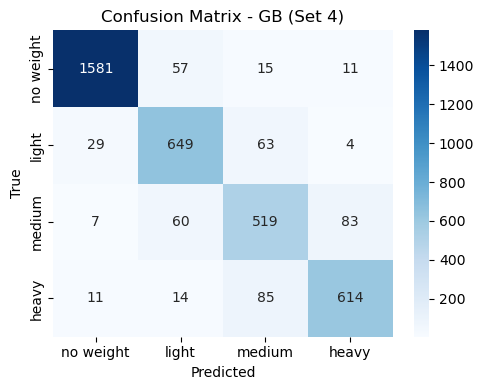

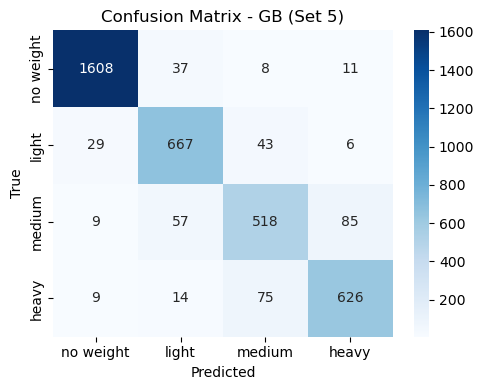

-------- GB Classifier - Evaluation Metrics --------
Accuracy: Set 1: 90.66% | Set 2: 90.01% | Set 3: 88.51% | Set 4: 88.45% | Set 5: 89.93%
Precision: Set 1: 90.69% | Set 2: 90.07% | Set 3: 88.63% | Set 4: 88.62% | Set 5: 89.92%
Recall: Set 1: 90.66% | Set 2: 90.01% | Set 3: 88.51% | Set 4: 88.45% | Set 5: 89.93%
F1: Set 1: 90.67% | Set 2: 90.03% | Set 3: 88.55% | Set 4: 88.52% | Set 5: 89.91%
Training_time: Set 1: 54.4267 s | Set 2: 35.3342 s | Set 3: 29.0704 s | Set 4: 42.3173 s | Set 5: 24.3403 s
Inference_time: Set 1: 4.8204 ms | Set 2: 4.7535 ms | Set 3: 4.7429 ms | Set 4: 5.1106 ms | Set 5: 5.0194 ms


In [31]:
#################################### Gradient Boosting ########################
model_name = 'GB'
gb_params = {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'min_samples_split': 5, 'max_features': 'sqrt'}
folder = f"{output_folder}/{model_name}"
evaluate_and_store_results(feature_sets_train, feature_sets_test, y_train, y_test, model_name, results, folder, gb_params)
print_results(model_name, results[model_name])

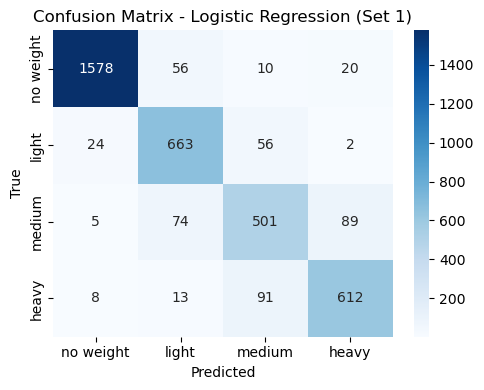

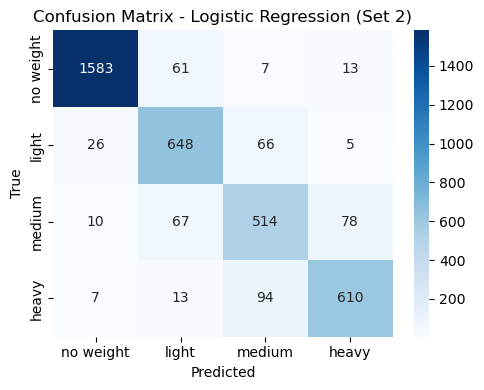

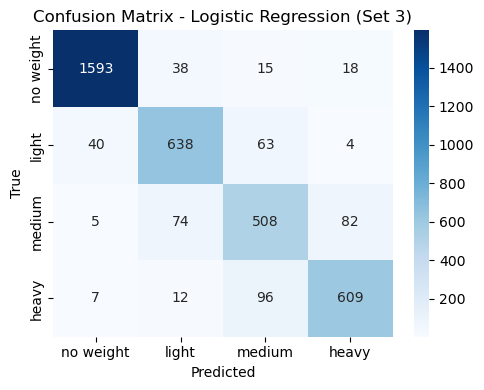

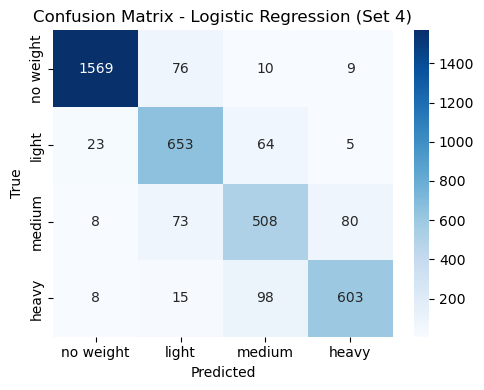

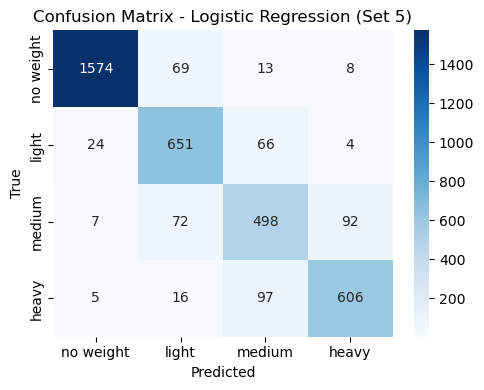

-------- Logistic Regression Classifier - Evaluation Metrics --------
Accuracy: Set 1: 88.22% | Set 2: 88.24% | Set 3: 88.06% | Set 4: 87.66% | Set 5: 87.56%
Precision: Set 1: 88.40% | Set 2: 88.44% | Set 3: 88.16% | Set 4: 87.99% | Set 5: 87.83%
Recall: Set 1: 88.22% | Set 2: 88.24% | Set 3: 88.06% | Set 4: 87.66% | Set 5: 87.56%
F1: Set 1: 88.27% | Set 2: 88.32% | Set 3: 88.10% | Set 4: 87.77% | Set 5: 87.65%
Training_time: Set 1: 0.2984 s | Set 2: 0.1174 s | Set 3: 0.0573 s | Set 4: 0.0815 s | Set 5: 0.0761 s
Inference_time: Set 1: 1.4066 ms | Set 2: 1.2195 ms | Set 3: 1.0641 ms | Set 4: 1.0539 ms | Set 5: 1.0518 ms


In [32]:
#################################### Logistic Regression ########################
# Logistic Regression is not included in LibEMG. Therefore, skicit_learn is used.
from sklearn.linear_model import LogisticRegression

model_name = 'Logistic Regression'
lr_params = {'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000, 'class_weight': 'balanced'}
folder = f"{output_folder}/{model_name}"

results[model_name] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'training_time': [], 'inference_time': []}

for i, (X_train, X_test) in enumerate(zip(feature_sets_train, feature_sets_test), start=1):
    model = LogisticRegression(**lr_params)
    
    start_time = time.time() 
    model.fit(X_train, y_train) # Fit the model
    end_time = time.time() 
    tr_time = (end_time - start_time)

    prediction_times = []
    all_preds = []
    
    for j in range(X_test.shape[0]):
        start_time = time.time()
        preds = model.predict(X_test[j:j+1])
        end_time = time.time()
        prediction_times.append(end_time - start_time)
        all_preds.append(preds)
    
    pred_time = np.mean(prediction_times) 
    preds = np.array(all_preds) 

    # Plot confusion matrix
    cm = confusion_matrix(y_test, preds)
    class_names = ['no weight', 'light', 'medium', 'heavy']
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    title = f'Confusion Matrix - {model_name}'
    title += f' (Set {i})'
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    #plt.savefig("mio_plot_alta_risoluzione.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    joblib.dump(model, f'{folder}/set_{i}.pkl')
    
    # Metrics
    acc = accuracy_score(y_test, preds) * 100
    precision = precision_score(y_test, preds, average='weighted', zero_division=0) * 100
    recall = recall_score(y_test, preds, average='weighted', zero_division=0) * 100
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0) * 100
    
    results[model_name]['accuracy'].append(acc)
    results[model_name]['precision'].append(precision)
    results[model_name]['recall'].append(recall)
    results[model_name]['f1'].append(f1)
    results[model_name]['training_time'].append(tr_time)
    results[model_name]['inference_time'].append(pred_time)

print_results(model_name, results[model_name])

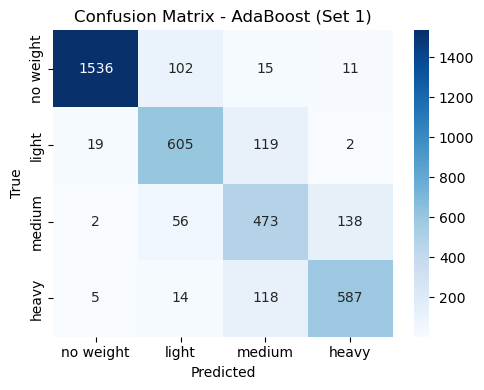

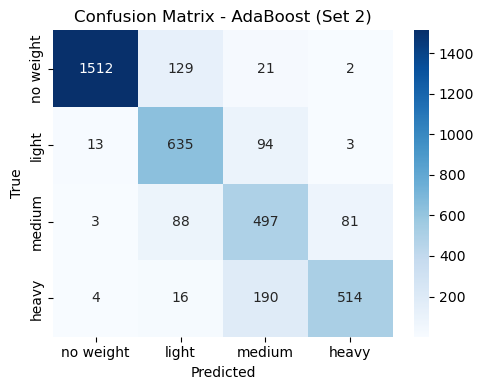

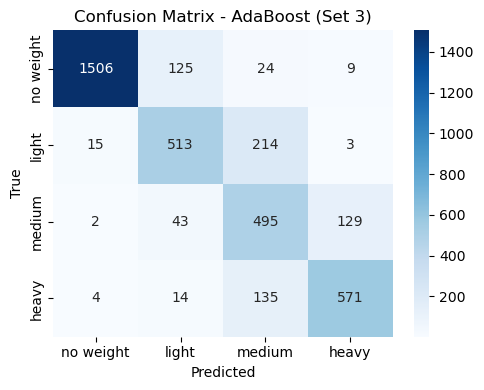

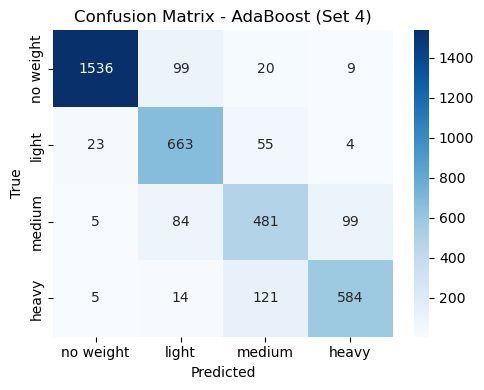

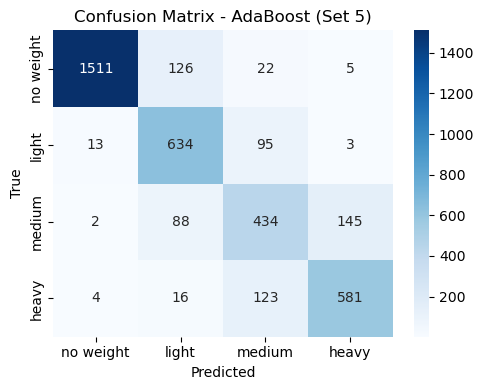

-------- AdaBoost Classifier - Evaluation Metrics --------
Accuracy: Set 1: 84.19% | Set 2: 83.06% | Set 3: 81.14% | Set 4: 85.85% | Set 5: 83.11%
Precision: Set 1: 84.92% | Set 2: 84.75% | Set 3: 82.93% | Set 4: 86.43% | Set 5: 84.01%
Recall: Set 1: 84.19% | Set 2: 83.06% | Set 3: 81.14% | Set 4: 85.85% | Set 5: 83.11%
F1: Set 1: 84.49% | Set 2: 83.51% | Set 3: 81.75% | Set 4: 86.01% | Set 5: 83.40%
Training_time: Set 1: 2.5331 s | Set 2: 1.2385 s | Set 3: 0.6570 s | Set 4: 1.2431 s | Set 5: 0.4784 s
Inference_time: Set 1: 8.3330 ms | Set 2: 8.2996 ms | Set 3: 8.1315 ms | Set 4: 8.3391 ms | Set 5: 8.6053 ms


In [33]:
#################################### ADA Boost ########################
# ADA Boost is not included in LibEMG. Therefore, skicit_learn is used.
from sklearn.ensemble import AdaBoostClassifier

model_name = 'AdaBoost'
ada_params = {'n_estimators': 50, 'learning_rate': 0.5, 'algorithm': 'SAMME'}
folder = f"{output_folder}/{model_name}"

results[model_name] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'training_time': [], 'inference_time': []}

for i, (X_train, X_test) in enumerate(zip(feature_sets_train, feature_sets_test), start=1):
    model = AdaBoostClassifier(**ada_params)
    
    start_time = time.time() 
    model.fit(X_train, y_train) # Fit the model
    end_time = time.time() 
    tr_time = (end_time - start_time)

    prediction_times = []
    all_preds = []
    
    for j in range(X_test.shape[0]):
        start_time = time.time()
        preds = model.predict(X_test[j:j+1])
        end_time = time.time()
        prediction_times.append(end_time - start_time)
        all_preds.append(preds)
    
    pred_time = np.mean(prediction_times) 
    preds = np.array(all_preds) 

    # Plot confusion matrix
    cm = confusion_matrix(y_test, preds)
    class_names = ['no weight', 'light', 'medium', 'heavy']
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    title = f'Confusion Matrix - {model_name}'
    title += f' (Set {i})'
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    
    # Metrics
    acc = accuracy_score(y_test, preds) * 100
    precision = precision_score(y_test, preds, average='weighted', zero_division=0) * 100
    recall = recall_score(y_test, preds, average='weighted', zero_division=0) * 100
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0) * 100

    joblib.dump(model, f'{folder}/set_{i}.pkl')
    
    results[model_name]['accuracy'].append(acc)
    results[model_name]['precision'].append(precision)
    results[model_name]['recall'].append(recall)
    results[model_name]['f1'].append(f1)
    results[model_name]['training_time'].append(tr_time)
    results[model_name]['inference_time'].append(pred_time)

print_results(model_name, results[model_name])

In [34]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'training_time', 'inference_time']
model_names = list(results.keys())
n_sets = len(next(iter(results.values()))['accuracy'])

for i in range(n_sets):
    rows = []
    for model in model_names:
        r = results[model]
        row = {
            'Model': model,
            'Accuracy': round(r['accuracy'][i], 2),
            'Precision': round(r['precision'][i], 2),
            'Recall': round(r['recall'][i], 2),
            'F1 Score': round(r['f1'][i], 2),
            'Training Time (s)': round(r['training_time'][i], 4),
            'Inference Time (ms)': round(r['inference_time'][i] * 1000, 4)
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    df_sorted = df.sort_values(by='Accuracy', ascending=False)

    print(f"\n📊 Evaluation Results - Test Set {i+1}")
    print(df_sorted.to_string(index=False))
    df_sorted.to_csv(f'{output_folder}/_results/results_test_set_{i+1}.csv', index=False)


📊 Evaluation Results - Test Set 1
              Model  Accuracy  Precision  Recall  F1 Score  Training Time (s)  Inference Time (ms)
                 GB     90.66      90.69   90.66     90.67            54.4267               4.8204
                 RF     89.48      89.55   89.48     89.50             0.3956              25.7775
                SVM     89.19      89.21   89.19     89.19             4.7109               1.4498
                KNN     88.98      89.04   88.98     89.00             0.0053               1.6057
                MLP     88.66      88.67   88.66     88.62             3.6433               1.1754
Logistic Regression     88.22      88.40   88.22     88.27             0.2984               1.4066
                 NB     86.64      86.99   86.64     86.72             0.0080               1.5410
           AdaBoost     84.19      84.92   84.19     84.49             2.5331               8.3330

📊 Evaluation Results - Test Set 2
              Model  Accuracy  Precisio